In [5]:
from sklearn import datasets
from sklearn import model_selection as skms
%matplotlib inline
diabetes = datasets.load_diabetes()
d_tts = skms.train_test_split(diabetes.data,
                              diabetes.target,
                              test_size=.25,
                              random_state=42)
(diabetes_train_ftrs, diabetes_test_ftrs,
 diabetes_train_tgt,  diabetes_test_tgt) = d_tts

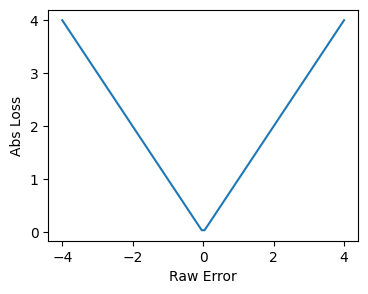

In [6]:
import numpy as np
import matplotlib.pyplot as plt

error = np.linspace(-4, 4, 100)
loss = np.abs(error)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(error, loss)

ax.set_xlabel('Raw Error')
ax.set_ylabel('Abs Loss');

In [7]:
an_error = .75
abs_error = abs(an_error)
if abs_error < 1.0:
    the_loss = 0.0
else:
    the_loss = abs_error
print(the_loss)

0.0


In [8]:
an_error = 0.75
adj_error = abs(an_error) - 1.0
if adj_error < 0.0:
    the_loss = 0.0
else:
    the_loss = adj_error
print(the_loss)

0.0


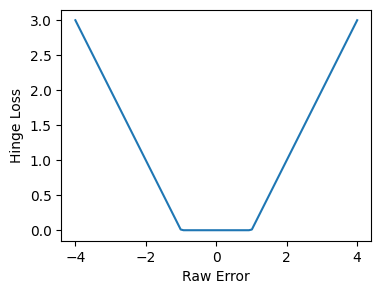

In [9]:
error = np.linspace(-4, 4, 100)

# ignoriramo greške manje od 1.0
loss = np.maximum(np.abs(error) - 1.0,
                  np.zeros_like(error))

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(error, loss)

ax.set_xlabel("Raw Error")
ax.set_ylabel("Hinge Loss");

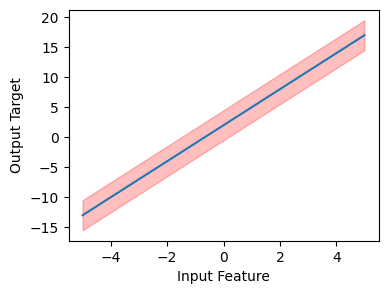

In [10]:
threshold = 2.5

xs = np.linspace(-5,5,100)
ys_true = 3 * xs + 2

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(xs, ys_true)
ax.fill_between(xs, ys_true-threshold, ys_true+threshold,
                 color=(1.0,0,0,.25))

ax.set_xlabel('Input Feature')
ax.set_ylabel('Output Target');

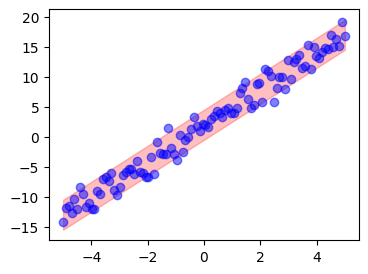

In [11]:
threshold = 2.5

xs = np.linspace(-5,5,100)
ys = 3 * xs + 2 + np.random.normal(0, 1.5, 100)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(xs, ys, 'o',  color=(0,0,1.0,.5))
ax.fill_between(xs, ys_true - threshold, ys_true + threshold,
                 color=(1.0,0,0,.25));

In [12]:
# hiperparametri
C, epsilon = 1.0, .25
# parametar
weights = np.array([1.3])

In [13]:
# prediction, error, loss
def rdot(arr,brr):
    return np.dot(brr,arr)
predictions = rdot(weights, xs.reshape(-1, 1))
errors = ys - predictions
loss_sse   = np.sum(errors ** 2)
loss_sae   = np.sum(np.abs(errors))
loss_hinge = np.sum(np.max(np.abs(errors) - epsilon, 0))

In [14]:
# complexity penalty for regularization
complexity_saw = np.sum(np.abs(weights))
complexity_ssw = np.sum(weights**2)

In [15]:
# cost
cost_gof_regression   = loss_sse   + 0.0
cost_L1pen_regression = loss_sse   + C * complexity_saw
cost_L2pen_regression = loss_sse   + C * complexity_ssw
cost_sv_regression    = loss_hinge + C * complexity_ssw
print(cost_gof_regression,cost_L1pen_regression)
print(cost_L2pen_regression, cost_sv_regression)

3081.5412807675484 3082.8412807675486 3083.2312807675485 14.283396701051403


In [16]:
from sklearn import svm
from sklearn import metrics
svrs = [svm.SVR(),   # default epsilon=0.1
        svm.NuSVR()] # default nu=0.5
for model in svrs:
    preds = (model.fit(diabetes_train_ftrs, diabetes_train_tgt)
                  .predict(diabetes_test_ftrs))
    print(metrics.mean_squared_error(diabetes_test_tgt, preds))

4511.870338681654
4608.840546363738
